In [14]:
import numpy as np

In [15]:
def generateAffineMatrix3D(matrix_affineA, matrix_affineAdash):
    # 各行列から平行移動を含む点を抽出
    points_A = np.array([mat[:3, 3] for mat in matrix_affineA])  # Aの各点 (x, y, z)
    points_Adash = np.array([mat[:3, 3] for mat in matrix_affineAdash])  # Adashの各点 (x', y', z')
    
    # アフィン変換行列を求めるための最小二乗法
    ones = np.ones((points_A.shape[0], 1))  # 点数分の1列
    P = np.hstack((points_A, ones))  # Aの点を拡張 [x, y, z, 1]
    print("P")
    print(P)
    Q = points_Adash  # Adashの点
    print("Q")
    print(Q)
    
    # 最小二乗法で解を求める
    affine_matrix, _, _, _ = np.linalg.lstsq(P, Q, rcond=None)
    print("affine_matrix")
    print(affine_matrix)

    # 4x4のアフィン変換行列を構築
    affine_matrix_4x4 = np.eye(4)
    affine_matrix_4x4[:3, :] = affine_matrix.T
    
    return affine_matrix_4x4

def generateAffineMatrix3DSelf(matrix_affineA, matrix_affineAdash):
    # Aの点を拡張 [x, y, z, 1]
    points_A = np.array([mat[:3, 3] for mat in matrix_affineA])
    points_Adash = np.array([mat[:3, 3] for mat in matrix_affineAdash]) 
    
    # P = points_A
    P = np.hstack((points_A, np.ones((points_A.shape[0], 1))))
    # P = np.vstack((P, np.array([1, 1, 1, 1])))
    # print(P)
    Q = points_Adash
    # Q = np.hstack((points_Adash, np.ones((points_Adash.shape[0], 1))))
    # Q = np.vstack((Q, np.array([1, 1, 1, 1])))

    # print(Q)
    
    # 最小二乗法で解を求める
    affine_matrix = leastSquaresMethod(P, Q)
    
    # 4x4のアフィン変換行列を構築
    affine_matrix = np.vstack((affine_matrix.T, np.array([0, 0, 0, 1])))
    
    return affine_matrix

def generateAffineMatrix3DSelfLU(matrix_affineA, matrix_affineAdash):
    """LU分解を用いた最小二乗法でアフィン変換行列を求める"""
    points_A = np.array([mat[:3, 3] for mat in matrix_affineA])
    points_Adash = np.array([mat[:3, 3] for mat in matrix_affineAdash]) 
    
    # 拡張行列を作成
    P = np.hstack((points_A, np.ones((points_A.shape[0], 1))))
    print("P")
    print(P)
    Q = points_Adash
    print("Q")
    print(Q)

    # 最小二乗法で解を求める
    affine_matrix = leastSquaresMethodLU(P, Q)

    print("affine_matrix")
    print(affine_matrix)

    # 4x4のアフィン変換行列を構築
    affine_matrix = np.vstack((affine_matrix.T, np.array([0, 0, 0, 1])))

    return affine_matrix

def LU(A: np.array) -> np.array:
    """LU分解"""
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            U[i, j] = A[i, j] - np.sum(L[i, :i] * U[:i, j])
        # print("U")
        # print(U)
        for j in range(i + 1, n):
            L[j, i] = (A[j, i] - np.sum(L[j, :i] * U[:i, i])) / U[i, i]
        # print("L")
        # print(L)

    return L, U

def eq_solve(P: np.array, Q: np.array) -> np.array:
    # LU分解
    L, U = LU(P)
    print("L")
    print(L)
    print("U")
    print(U)
    n, m = Q.shape  # Q の形状を取得
    y = np.zeros((n, m))  # 前進代入の解ベクトル y を用意

    # 前進代入
    for i in range(n):
        print("Q[i][k],dot",i)
        print(Q[i, :],np.dot(L[i, :i], y[:i, :]))
        y[i, :] = Q[i, :] - np.dot(L[i, :i], y[:i, :])

    print("y")
    print(y)

    x = np.zeros((n, m))  # 解ベクトル x を用意

    # 後退代入
    for i in range(n - 1, -1, -1):
        if np.abs(U[i, i]) < 1e-8:  # 0除算防止
            print(f"Warning: U[{i}, {i}] is nearly zero. Adding small value.")
            U[i, i] = 1e-8
        print(f"np.dot({U[i, i+1:]}, {x[i+1:, :]})")
        print(y[i, :],"\n",np.dot(U[i, i+1:], x[i+1:, :]),"\n",U[i, i])
        x[i, :] = (y[i, :] - np.dot(U[i, i+1:], x[i+1:, :])) / U[i, i]
        print(f"x {i}")
        print(x)

    print("x")
    print(x)
    return x

def leastSquaresMethod(P: np.array, Q: np.array) -> np.array:
    # 最小二乗法と逆行列を用いた解法
    affine_matrix = np.linalg.inv(P.T @ P) @ P.T @ Q
    return affine_matrix

def leastSquaresMethodLU(P: np.array, Q: np.array) -> np.array:
    # 最小二乗法で解を求める
    affine_matrix = eq_solve(P.T @ P, P.T) @ Q
    print("eq_solve(P.T @ P, P.T)")
    print(eq_solve(P.T @ P, P.T))
    print("Q")
    print(Q)
    return affine_matrix

def leastSquaresMethod(P: np.array, Q: np.array) -> np.array:
    # 最小二乗法で解を求める
    affine_matrix = np.linalg.solve(P.T @ P, P.T) @ Q
    return affine_matrix

In [16]:
myrightIndexFingerCoordinates = np.array([
    [0.71980065,-0.5799738,0.38146743,0],
    [0.6828775,0.49282372,-0.53926146,0],
    [0.12476139,0.6486563,0.75078607,0],
    [-0.3264044,0.8889144,-0.38876295,1.0000001]
])

In [17]:
myBothIndexFingerCoordinateRight = np.array([[0.71980065,-0.5799738,0.38146743,0],[0.6828775,0.49282372,-0.53926146,0],[0.12476139,0.6486563,0.75078607,0],[-0.3264044,0.8889144,-0.38876295,1.0000001]])
myBothIndexFingerCoordinateLeft = np.array([[-0.16631845,0.75672364,-0.6322248,0],[-0.87949944,-0.40376356,-0.25190488,0],[-0.44589153,0.51414484,0.7326913,0],[-0.3359995,0.87302464,-0.30071822,1]])

In [18]:
resRightIndexFingerCoordinates = np.array([[0.71980065,-0.5799738,0.38146743,0],[0.6828775,0.49282372,-0.53926146,0],[0.12476139,0.6486563,0.75078607,0],[-0.3264044,0.8889144,-0.38876295,1.0000001]])

In [19]:
resBothIndexFingerCoordinateRight = np.array([[0.71980065,-0.5799738,0.38146743,0],[0.6828775,0.49282372,-0.53926146,0],[0.12476139,0.6486563,0.75078607,0],[-0.3264044,0.8889144,-0.38876295,1.0000001]])
resBothIndexFingerCoordinateLeft = np.array([[-0.16631845,0.75672364,-0.6322248,0],[-0.87949944,-0.40376356,-0.25190488,0],[-0.44589153,0.51414484,0.7326913,0],[-0.3359995,0.87302464,-0.30071822,1]])

In [20]:
matrix_affine1 = np.array([
    myrightIndexFingerCoordinates.T,
    myBothIndexFingerCoordinateRight.T,
    myBothIndexFingerCoordinateLeft.T
])


matrix_affine2 = np.array([
    resRightIndexFingerCoordinates.T,
    resBothIndexFingerCoordinateRight.T,
    resBothIndexFingerCoordinateLeft.T
])

matrix_affine1 = np.array([[[0.29195672273635864, 0.20753134787082672, -0.9336443543434143, 0.3406505584716797], [0.10483368486166, 0.9633494019508362, 0.24691641330718994, 1.0227067470550537], [0.950668454170227, -0.16996638476848602, 0.25950002670288086, -0.4758530557155609], [0.0, 0.0, 0.0, 0.9999997019767761]], [[0.8126243948936462, -0.1172361671924591, -0.5708739757537842, 0.25409597158432007], [-0.23279379308223724, -0.9633129239082336, -0.13354729115962982, 1.0099575519561768], [-0.5342738628387451, 0.2414197027683258, -0.8101032972335815, -0.4570466876029968], [0.0, 0.0, 0.0, 0.9999997615814209]], [[-0.03469759598374367, 0.003780881641432643, -0.9993905425071716, 0.4099700152873993], [-0.5030160546302795, 0.8640282154083252, 0.02073289453983307, 1.005720853805542], [0.8635802268981934, 0.5034287571907043, -0.028077878057956696, -0.37334659695625305], [0.0, 0.0, 0.0, 0.9999998211860657]]])
matrix_affine2 = np.array([[[0.45655980706214905, 0.7681077122688293, 0.44895800948143005, -0.26391538977622986], [-0.23043100535869598, -0.38531294465065, 0.8935520052909851, 0.9078537225723267], [0.8593336939811707, -0.5114138126373291, 0.0010774779366329312, -0.5531684756278992], [0.0, 0.0, 0.0, 1.0]], [[0.011919788084924221, -0.8203105926513672, -0.5717933177947998, -0.35877254605293274], [0.4230100214481354, -0.5140084028244019, 0.7462285757064819, 0.9013289213180542], [-0.9060462713241577, -0.25076937675476074, 0.34087279438972473, -0.5011917948722839], [0.0, 0.0, 0.0, 0.9999998807907104]], [[0.4490292966365814, 0.4107557237148285, -0.7935065627098083, -0.29981839656829834], [-0.8199097514152527, 0.5423877835273743, -0.18320521712303162, 0.9066635370254517], [0.35513556003570557, 0.7328680157661438, 0.5803306698799133, -0.6528453826904297], [0.0, 0.0, 0.0, 1.0000001192092896]]])


print(matrix_affine1)
print(matrix_affine2)

affine_self_LU = generateAffineMatrix3DSelfLU(matrix_affine1, matrix_affine2)
print(affine_self_LU)

[[[ 0.29195672  0.20753135 -0.93364435  0.34065056]
  [ 0.10483368  0.9633494   0.24691641  1.02270675]
  [ 0.95066845 -0.16996638  0.25950003 -0.47585306]
  [ 0.          0.          0.          0.9999997 ]]

 [[ 0.81262439 -0.11723617 -0.57087398  0.25409597]
  [-0.23279379 -0.96331292 -0.13354729  1.00995755]
  [-0.53427386  0.2414197  -0.8101033  -0.45704669]
  [ 0.          0.          0.          0.99999976]]

 [[-0.0346976   0.00378088 -0.99939054  0.40997002]
  [-0.50301605  0.86402822  0.02073289  1.00572085]
  [ 0.86358023  0.50342876 -0.02807788 -0.3733466 ]
  [ 0.          0.          0.          0.99999982]]]
[[[ 0.45655981  0.76810771  0.44895801 -0.26391539]
  [-0.23043101 -0.38531294  0.89355201  0.90785372]
  [ 0.85933369 -0.51141381  0.00107748 -0.55316848]
  [ 0.          0.          0.          1.        ]]

 [[ 0.01191979 -0.82031059 -0.57179332 -0.35877255]
  [ 0.42301002 -0.5140084   0.74622858  0.90132892]
  [-0.90604627 -0.25076938  0.34087279 -0.50119179]
  [ 

In [21]:
affine = np.array([[1.001656169343471, -1.1592077232555298, -1.2197031145313115, -1.7563437603449016e-08], [-0.031375740387923345, 0.9780242765224307, 0.1716709356994901, -9.950440138531088e-10], [-0.6474430459248338, -0.621908587739342, -0.6376201116816667, -1.0251911737604204e-08], [0.0, 0.0, 0.0, 1.0]])


boxTransform = np.array([[-0.96216965, -1.1595521, -1.2507681, -1.7563437e-08], [0.16008803, 0.97805184, 0.06908923, -9.95044e-10], [-0.76720524, -0.621865, 0.48702347, -1.0251911e-08], [0.05558767, 0.8801734, -0.33377427, 1.0]])

default_boxTransform = boxTransform * np.linalg.inv(affine)
print(default_boxTransform)

[[-4.28035373e-01  1.93721124e-02  1.07000653e+00  1.70992367e-17]
 [ 1.80719579e-02  1.20245590e+00  7.94996237e-03 -4.36397339e-18]
 [ 4.31034438e-01  7.35157258e-01 -3.95417219e-01  1.98553615e-16]
 [ 0.00000000e+00  0.00000000e+00 -0.00000000e+00  1.00000000e+00]]


In [22]:
import japanize_matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

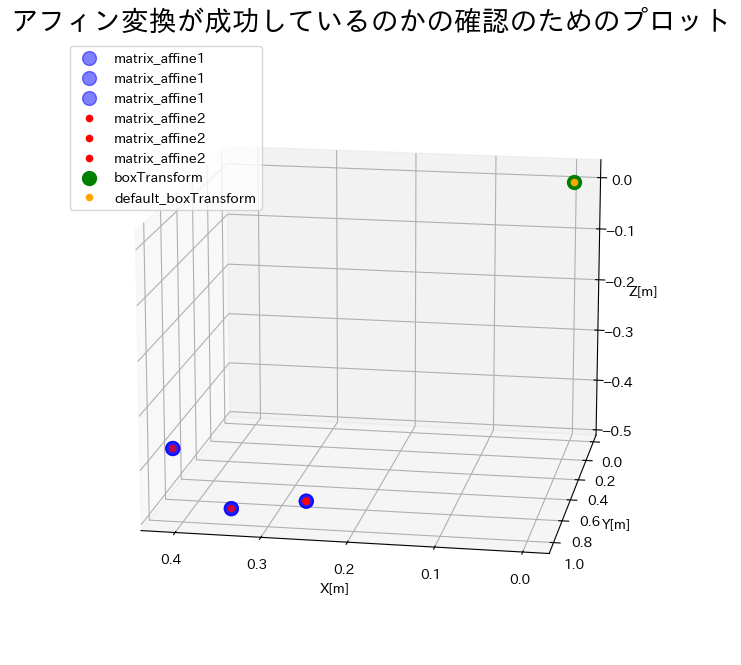

In [23]:
# 3D plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# matrix_affine1, matrix_affine2の座標
for mat in matrix_affine1:
    points = np.array([mat[:3, 3] for mat in matrix_affine1])
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c="blue", alpha=0.5, s=100, label="matrix_affine1")

matrix_affine2 = np.einsum('ij,klj->kli', affine, matrix_affine1)
for mat in matrix_affine2:
    points = np.array([mat[:3, 3] for mat in matrix_affine2])
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c="red", label="matrix_affine2")

# 3D plot boxTransform
default_points = np.array([default_boxTransform[:3, 3]])
# print(default_points[:, 0], default_points[:, 1], default_points[:, 2])
ax.scatter(default_points[:, 0], default_points[:, 1], default_points[:, 2], c="green", s=100, label="boxTransform")

points = np.array([boxTransform[:3, 3]])
# print(points[:, 0], points[:, 1], points[:, 2])
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c="orange", label="default_boxTransform")


ax.set_xlabel("X[m]")
ax.set_ylabel("Y[m]")
ax.set_zlabel("Z[m]")
ax.legend()
ax.set_title("アフィン変換が成功しているのかの確認のためのプロット", fontsize=20)

ax.view_init(elev=15, azim=100)

plt.show()
